In [2]:
import time
import os
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
import corner
from scipy import optimize
from simple_pe.param_est.pe import SimplePESamples
from simple_pe.param_est.filter import matched_filter_network
from simple_pe.waveforms import waveform, waveform_modes, eccentric
from simple_pe import io
from pesummary.io import read
from pesummary.utils.samples_dict import SamplesDict
from pesummary.gw.conversions.mass import q_from_eta, component_masses_from_mchirp_q

import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this p

lal.MSUN_SI != Msun


In [15]:
# Load run files
dir_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_1/outdir/output'
inj_path = os.path.join(dir_path, 'converted_injection_parameters.json')
with open(inj_path, 'r') as f:
    all_inj_params = json.load(f)
peak_path = os.path.join(dir_path, 'peak_parameters.json')
with open(peak_path, 'r') as f:
    all_peak_params = json.load(f)
metric_path = os.path.join(dir_path, 'analysis_metric.pkl')
with open(metric_path, 'rb') as f:
    analysis_metric = pickle.load(f)
samples_path = os.path.join(dir_path, 'posterior_samples.dat')
samples = SimplePESamples(read(samples_path).samples_dict)

# Load psds
asds = {'H1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
        'L1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
        'V1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/avirgo_O4high_NEW.txt'}
psds = io.load_psd_from_file([], asds, 1/32, 15, 2048)

# Load data
trig_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_1/trigger_parameters.json'
strain_paths = {'H1': os.path.join(dir_path, 'H1-INJECTION.gwf'),
                'L1': os.path.join(dir_path, 'L1-INJECTION.gwf'),
                'V1': os.path.join(dir_path, 'V1-INJECTION.gwf')}
trigger_parameters = io.load_trigger_parameters_from_file(trig_path, 'TEOBResumS-Dali')
_, data = io.load_strain_data_from_file(
    trigger_parameters, strain_paths, {'H1':'HWINJ_INJECTED', 'L1':'HWINJ_INJECTED', 'V1':'HWINJ_INJECTED'}, 10,
    2048, minimum_data_length=32
)

If we use dx coordinates of the metric, can we optimise over each direction independently once we are close to the peak? Let's see first how different this is for the metric calculated at the peak non-eccentric point (filter_metric) and the current final peak eccentric point (analysis_metric).

One challenge here is that each metric has an infinite number of sets of orthogonal vectors, of which the dx coordinates are just an arbitrary choice in each case, so we cannot simply compare the eigenvectors of each metric. Instead I will convert eigenvectors of the filter metric into the dx space of the analysis metric and measure orthogonality.

It is clear that these are not very orthogonal. We therefore cannot just use the metric calculated at the non-eccentric peak as an approximation of the metric at the peak of the degeneracy line. Instead plan to use zeroth iteration to calculate metric at non-eccentric peak point, and then perform another iteration at the peak of the degeneracy line using the eigenvectors of the first metric as a starting point.

For this proof of concept study will simply use the eigenvectors of the analysis metric which should be quite accurate.

In fact, find that Powell method of scipy.optimize.minimize already implements this idea of optimizing in 1d directions sequentially, so we can simply use that.

In [16]:
def _neg_net_snr_extra(
    x, ifos, data, psds, t_start, t_end, f_low, approximant,
    ecc_harms, metric, maxs=None, mins=None, fixed_pars=None, harm2=False, verbose=False
):

    # Check in bounds
    delta_params_list = np.matmul(metric.normalized_evecs().samples, x)
    delta_params = SimplePESamples(SamplesDict(metric.dx_directions, [[param] for param in delta_params_list]))
    alpha = waveform.check_physical(metric.x, delta_params, 1, maxs=maxs, mins=mins)
    params = [delta_params[dx][0] + metric.x[dx][0] for dx in metric.dx_directions]
    s = dict(zip(metric.dx_directions, params))
    if fixed_pars is not None:
        s.update(fixed_pars)
    if verbose:
        print(f'making waveform with dx coords {x} at parameters')
        print(s)
    if alpha < 1:
        print('out of bounds')
        return 0

    try:
        z_ecc = {}
        modes = [0, 1, -1]
        for ifo in ifos:
            z_ecc[ifo], _ = waveform_modes.calculate_mode_snr(
                data[ifo], psds[ifo], ecc_harms[ifo], t_start, t_end, f_low, modes,
                subsample_interpolation=True, dominant_mode=0
            )
        _, mode_snrs = waveform_modes.network_mode_snr(
            z_ecc, ifos, modes, dominant_mode=0, return_cplx=True
        )
        _, target_ma = waveform_modes.two_ecc_harms_snr(
            {k: np.abs(mode_snrs[k]) for k in [0, 1, -1]},
            {k: np.angle(mode_snrs[k]) for k in [0, 1, -1]}
        )
        q = q_from_eta(s['symmetric_mass_ratio'])
        m_total = np.sum(component_masses_from_mchirp_q(s['chirp_mass'], q))
    
        harm_psd = io.calculate_harmonic_mean_psd(psds)
        h = eccentric.generate_eccentric_waveform_ma(
            m_total, q,
            s['ecc10sqrd']**0.5, s['chi_align'],
            s['chi_align'], harm_psd, f_low, target_ma, ecc_harms['harm'],
            align_merger=True, to_fs=True
        )

    except RuntimeError:
        print('error making waveform')
        return np.inf

    s = matched_filter_network(
        ifos, data, psds, t_start, t_end, h, f_low,
        subsample_interpolation=True
    )[0]

    if verbose:
        print('snr = %.4f' % s)

    return -s

In [17]:
# Set up
ifos = list(psds.keys())
t_start = trigger_parameters['time']-0.1
t_end = trigger_parameters['time']+0.1
dx_directions = ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd']
fixed_pars = {}

# Create eccentric harmonics
params = {key: all_peak_params['posterior_samples'][key] for key in dx_directions}
ecc_harm_psds = psds.copy()
ecc_harm_psds['harm'] = io.calculate_harmonic_mean_psd(psds)
ecc_harms = waveform.make_waveform(params, psds[ifos[0]].delta_f, 20, len(psds[ifos[0]]), 'TEOBResumS-Dali-Harms', n_ecc_gen=6, n_ecc_harms=3, ecc_harm_psd=ecc_harm_psds)

In [24]:
# Perform optimisation using scipy.optimize.minimize
start = time.time()
out = optimize.minimize(
    _neg_net_snr_extra, [0, 0, 0, 0], args=(
    ifos, data, psds, t_start, t_end,
    20, 'TEOBResumS-Dali', ecc_harms, analysis_metric, None, None, fixed_pars, False, True
    ), bounds=[(-1,1)], method='Powell', options={'maxiter': 1, 'direc': np.identity(4), 'xtol': 0.05, 'ftol': np.inf}
)
end = time.time()
print(f'{end-start:.2f} seconds')
print(f'SNR: {-out.fun:.4f}, nfev: {out.nfev}')
print(out.x)

making waveform with dx coords [0. 0. 0. 0.] at parameters
{'chirp_mass': 30.30046706834873, 'symmetric_mass_ratio': 0.2372086717564731, 'chi_align': 0.09050120667666045, 'ecc10sqrd': 0.016855374011666882}


/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


snr = 20.4830
making waveform with dx coords [-0.23606798  0.          0.          0.        ] at parameters
{'chirp_mass': 30.30051429575404, 'symmetric_mass_ratio': 0.23545904286460906, 'chi_align': 0.09003619651167936, 'ecc10sqrd': 0.017237044672824765}
snr = 20.4988
making waveform with dx coords [0.23606798 0.         0.         0.        ] at parameters
{'chirp_mass': 30.30041984094342, 'symmetric_mass_ratio': 0.23895830064833712, 'chi_align': 0.09096621684164154, 'ecc10sqrd': 0.016473703350509}
snr = 20.4588
making waveform with dx coords [-0.52786405  0.          0.          0.        ] at parameters
{'chirp_mass': 30.300572672037404, 'symmetric_mass_ratio': 0.23329638261886748, 'chi_align': 0.08946141233753435, 'ecc10sqrd': 0.017708815555033196}
snr = 20.5075
making waveform with dx coords [-0.59148765  0.          0.          0.        ] at parameters
{'chirp_mass': 30.30058540047992, 'symmetric_mass_ratio': 0.23282483330060652, 'chi_align': 0.08933608563122485, 'ecc10sqrd': 

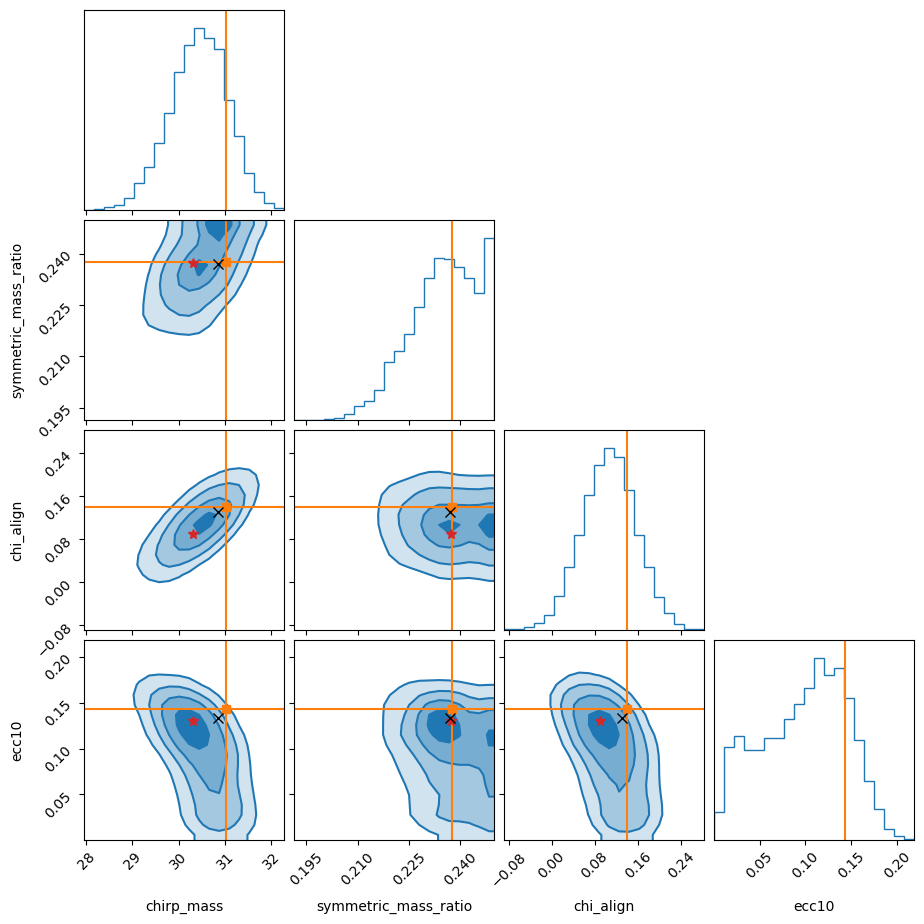

In [25]:
params = ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10']
corner_samples = np.array([samples[key] for key in params]).T
corner_truths = [all_inj_params['posterior_samples'][par][0] for par in params]
fig = corner.corner(corner_samples, truths=corner_truths, color='C0', truth_color='C1', smooth=1, labels=params, plot_density=False, plot_datapoints=False, fill_contours=True)
old_params = [all_peak_params['posterior_samples'][par][0] for par in params]
corner.overplot_points(fig, [old_params], c='C3', label='old peak', marker='*', markersize=7)
delta_params_list = np.matmul(analysis_metric.normalized_evecs().samples, out.x)
delta_params = SimplePESamples(SamplesDict(analysis_metric.dx_directions, [[param] for param in delta_params_list]))
new_params = [delta_params[dx][0] + analysis_metric.x[dx][0] for dx in ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd']]
new_params[-1] = np.sqrt(new_params[-1])
corner.overplot_points(fig, [new_params], c='k', label='new peak', marker='x', markersize=7)

In [26]:
all_inj_params['posterior_samples']['ecc10sqrd'] = [all_inj_params['posterior_samples']['ecc10'][0]**2]
inj_params_diff_old = [all_inj_params['posterior_samples'][par][0] - all_peak_params['posterior_samples'][par][0] for par in analysis_metric.dx_directions]
inj_dx_diff_old = np.matmul(np.linalg.inv(analysis_metric.normalized_evecs().samples), inj_params_diff_old)
dx_dist_old = np.sqrt(np.dot(inj_dx_diff_old, inj_dx_diff_old))
inj_dx_diff_new = np.array(inj_dx_diff_old) - np.array(out.x)
dx_dist_new = np.sqrt(np.dot(inj_dx_diff_new, inj_dx_diff_new))
print(f'Reduced dx distance from {dx_dist_old:.3f} to {dx_dist_new:.3f}')

Reduced dx distance from 0.970 to 0.290


This works as a nice proof of concept for this example, however in reality we will have to deal with prior imposing bounds on each of our 1D optimisations. This will have several effects: 

Firstly, returning an SNR of zero for points outside the prior will lead to biases in the 1D optimisations, as they try to treat the SNR as quadratic around the peak.

Secondly, the prior in dx coordinates will change depending on where we have reached in the previous 1D optimisation.

Finally, the prior may mean that although we rail against a physical prior bound in an earlier 1D optimisation, later optimisations may 'unlock' more parameter space in that direction.

Calling the Powell method for each 1D optimisation ourselves will allow us to dynamically change the bounds as required, and perform repeated optimisations in railing directions to fix this issue.

In [32]:
def func(x):
    return x**2

out = optimize.minimize(func, 2, bounds=[(-10, 10)], method='Nelder-Mead')

In [33]:
out.x[0]

-1.7763568394002505e-15

In [35]:
analysis_metric.dx_directions

['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd']

In [48]:
def _neg_net_snr_ecc(x, dx_directions, ifos, data, psds, t_start, t_end, f_low, approximant,
    target_ma, ecc_harms, fixed_pars=None, harm2=False, verbose=False, harm_psd=None
):
    s = dict(zip(dx_directions, x))
    if fixed_pars is not None:
        s.update(fixed_pars)

    if verbose:
        print('making waveform at parameters')
        print(s)
    try:
        q = q_from_eta(s['symmetric_mass_ratio'])
        m_total = np.sum(component_masses_from_mchirp_q(s['chirp_mass'], q))
        if harm_psd is None:
            harm_psd = io.calculate_harmonic_mean_psd(psds)
        h = eccentric.generate_eccentric_waveform_ma(
            m_total, q,
            s['ecc10sqrd']**0.5, s['chi_align'],
            s['chi_align'], harm_psd, f_low, target_ma, ecc_harms['harm'],
            align_merger=True, to_fs=True
        )
    except RuntimeError:
        print('error making waveform')
        return np.inf

    s = matched_filter_network(
        ifos, data, psds, t_start, t_end, h, f_low,
        subsample_interpolation=True
    )[0]

    if verbose:
        print('snr = %.4f' % s)

    return -s

def _neg_net_snr_metric(
    x, ind, current_point, ifos, data, psds, t_start, t_end, f_low, approximant,
    metric, ecc_harms=None, target_ma=None, harm_psd=None, maxs=None, mins=None, fixed_pars=None, harm2=False, verbose=False
):

    # Convert to physical parameters
    if verbose:
        print(f'trying dx coordinate of {x}')
    current_point[ind] = x
    delta_params_list = np.matmul(metric.normalized_evecs().samples, current_point)
    delta_params = SimplePESamples(SamplesDict(metric.dx_directions, [[param] for param in delta_params_list]))
    params = [delta_params[dx][0] + metric.x[dx][0] for dx in metric.dx_directions]

    # Call correct function
    if 'ecc10' in metric.dx_directions or 'ecc10sqrd' in metric.dx_directions:
        neg_s = _neg_net_snr_ecc(
            params, metric.dx_directions, ifos, data, psds, t_start, t_end, f_low, approximant,
            target_ma, ecc_harms, fixed_pars=fixed_pars, harm2=harm2, verbose=verbose, harm_psd=harm_psd
        )
    else:
        neg_s = _neg_net_snr(
            params, metric.dx_directions, ifos, data, psds, t_start, t_end, f_low, approximant,
            fixed_pars=fixed_pars, harm2=harm2, verbose=verbose
        )

    return neg_s

In [119]:
def calc_dx_bounds(current_point, dx_ind, metric, bound, maxs=None, mins=None):

    # Calculate unit change in physical parameters
    delta_dx = [0 for i in range(len(metric.dx_directions))]
    delta_dx[dx_ind] = 1
    delta_params_list = np.matmul(metric.normalized_evecs().samples, delta_dx)
    delta_params = SimplePESamples(SamplesDict(metric.dx_directions, [[param] for param in delta_params_list]))

    # Calculate current point in physical parameters
    current_delta_list = np.matmul(metric.normalized_evecs().samples, current_point)
    current_params = [[current_delta_list[i] + metric.x[dx][0]] for i, dx in enumerate(metric.dx_directions)]
    current_params = SimplePESamples(SamplesDict(metric.dx_directions, current_params))

    # Calculate allowed bounds
    lower_alpha = waveform.check_physical(current_params, delta_params, -bound, maxs=maxs, mins=mins)
    if lower_alpha < 1:
        lower_alpha = lower_alpha[0]
    upper_alpha = waveform.check_physical(current_params, delta_params, bound, maxs=maxs, mins=mins)
    if upper_alpha < 1:
        upper_alpha = upper_alpha[0]
    bounds = [(-lower_alpha*bound, upper_alpha*bound)]

    return bounds

def metric_peak_find(
    ifos, data, psds, t_start, t_end, f_low, approximant, metric,
    bound, tolerance, n_ecc_gen=6,
    maxs=None, mins=None, fixed_pars=None, harm2=False, verbose=False
):

    # Start optimisation
    iterating_inds = np.arange(len(metric.dx_directions))
    current_point = np.zeros(len(metric.dx_directions))
    ind_order = []
    harm_psd = io.calculate_harmonic_mean_psd(psds)
    while len(iterating_inds) > 0:
        start_iter_point = current_point.copy()
        start_iter_inds = iterating_inds.copy()

        # Calculate eccentric harmonics and target mean anomaly if required
        if 'ecc10' in metric.dx_directions or 'ecc10sqrd' in metric.dx_directions:
            delta_params_list = np.matmul(metric.normalized_evecs().samples, current_point)
            delta_params = SimplePESamples(SamplesDict(metric.dx_directions, [[param] for param in delta_params_list]))
            params = [delta_params[dx][0] + metric.x[dx][0] for dx in metric.dx_directions]
            s = dict(zip(metric.dx_directions, params))
            if fixed_pars is not None:
                s.update(fixed_pars)
            ecc_harm_psds = psds.copy()
            ecc_harm_psds['harm'] = harm_psd
            ecc_harms = waveform.make_waveform(s, psds[ifos[0]].delta_f, f_low, len(psds[ifos[0]]), f'{approximant}-Harms',
                                               n_ecc_gen=n_ecc_gen, n_ecc_harms=3, ecc_harm_psd=ecc_harm_psds)
            z_ecc = {}
            modes = [0, 1, -1]
            for ifo in ifos:
                z_ecc[ifo], _ = waveform_modes.calculate_mode_snr(
                    data[ifo], psds[ifo], ecc_harms[ifo], t_start, t_end, f_low, modes,
                    subsample_interpolation=True, dominant_mode=0
                )
            _, mode_snrs = waveform_modes.network_mode_snr(
                z_ecc, ifos, modes, dominant_mode=0, return_cplx=True
            )
            _, target_ma = waveform_modes.two_ecc_harms_snr(
                {k: np.abs(mode_snrs[k]) for k in [0, 1, -1]},
                {k: np.angle(mode_snrs[k]) for k in [0, 1, -1]}
            )
        else:
            ecc_harms = None
            target_ma = None

        # Optimise over each eigenvector
        working_inds = iterating_inds.copy()
        for i in range(len(iterating_inds)):

            # Decide optimisation order on first iteration
            if len(ind_order) < len(metric.dx_directions):
                # Calculate bounds for each eigenvector
                bounds_list = []
                bounds_size = []
                for j in working_inds:
                    bounds = calc_dx_bounds(current_point, j, metric, bound, maxs=maxs, mins=mins)
                    bounds_list.append(bounds)
                    bounds_size.append(np.abs(np.prod(bounds)))
    
                # Choose lowest range of bounds for next eigenvector
                print(bounds_list)
                print(bounds_size)
                next_ind = np.argmax(bounds_size)
                next_ev = working_inds[next_ind]
                next_bounds = bounds_list[next_ind]
                ind_order.append(next_ev)

            # Follow ind_order otherwise
            else:
                for ind in ind_order:
                    if ind in working_inds:
                        next_ev = ind
                        next_bounds = calc_dx_bounds(current_point, ind, metric, bound, maxs=maxs, mins=mins)
                        break
            
            working_inds = np.delete(working_inds, np.where(working_inds==next_ev))
            if verbose:
                print(f'optimising over dx ind {next_ev} with bounds {next_bounds}')

            # Perform optimisation
            out = optimize.minimize(
                _neg_net_snr_metric, current_point[next_ev], args=(
                next_ev, current_point, ifos, data, psds, t_start, t_end,
                f_low, approximant, analysis_metric, ecc_harms, target_ma, harm_psd,
                maxs, mins, fixed_pars, harm2, verbose
                ), bounds=next_bounds, method='Powell', options={'xtol': tolerance, 'ftol': np.inf}
            )
            current_point[next_ev] = out.x[0]
            if verbose:
                print(f'new peak point: {current_point}')

            # Check if railing in this direction
            not_lower_rail = np.abs(np.diff([out.x[0], next_bounds[0][0]])) > 3*tolerance
            not_upper_rail = np.abs(np.diff([out.x[0], next_bounds[0][1]])) > 3*tolerance
            if not_lower_rail and not_upper_rail:
                iterating_inds = np.delete(iterating_inds, np.where(iterating_inds==next_ev))
            elif verbose:
                print(f'dx ind {next_ev} is railing')                    

        # Stop if only direction left was just iterated over
        if len(iterating_inds) == 1 and iterating_inds[0] == next_ev:
            iterating_inds = []
        # Stop if peak point did not significantly change in last iteration
        elif len(iterating_inds) > 0:
            iter_change = current_point - start_iter_point
            iter_change_dist = np.sqrt(np.dot(iter_change, iter_change))
            if iter_change_dist < np.sqrt(len(start_iter_inds))*tolerance:
                iterating_inds = []

    return current_point

In [120]:
# Load run files
dir_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_2/outdir/output'
inj_path = os.path.join(dir_path, 'converted_injection_parameters.json')
with open(inj_path, 'r') as f:
    all_inj_params = json.load(f)
peak_path = os.path.join(dir_path, 'peak_parameters.json')
with open(peak_path, 'r') as f:
    all_peak_params = json.load(f)
metric_path = os.path.join(dir_path, 'analysis_metric.pkl')
with open(metric_path, 'rb') as f:
    analysis_metric = pickle.load(f)
samples_path = os.path.join(dir_path, 'posterior_samples.dat')
samples = SimplePESamples(read(samples_path).samples_dict)

# Load psds
asds = {'H1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
        'L1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
        'V1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/avirgo_O4high_NEW.txt'}
psds = io.load_psd_from_file([], asds, 1/32, 15, 2048)

# Load data
trig_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_2/trigger_parameters.json'
strain_paths = {'H1': os.path.join(dir_path, 'H1-INJECTION.gwf'),
                'L1': os.path.join(dir_path, 'L1-INJECTION.gwf'),
                'V1': os.path.join(dir_path, 'V1-INJECTION.gwf')}
trigger_parameters = io.load_trigger_parameters_from_file(trig_path, 'TEOBResumS-Dali')
_, data = io.load_strain_data_from_file(
    trigger_parameters, strain_paths, {'H1':'HWINJ_INJECTED', 'L1':'HWINJ_INJECTED', 'V1':'HWINJ_INJECTED'}, 10,
    2048, minimum_data_length=32
)

# Set up
ifos = list(psds.keys())
t_start = trigger_parameters['time']-0.1
t_end = trigger_parameters['time']+0.1
f_low = 20
approximant = 'TEOBResumS-Dali'
fixed_pars = {}

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [121]:
metric_peak = metric_peak_find(
    ifos, data, psds, t_start, t_end, f_low, approximant, analysis_metric,
    3, 0.01, n_ecc_gen=6,
    maxs=None, mins=None, fixed_pars=None, harm2=False, verbose=True
)

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


[[(-0.3872797328319655, 3.0)], [(-0.2543798251049019, 1.8819759662462607)], [(-3.0, 0.13685148670876587)], [(-0.22067567846357689, 3.0)]]
[1.1618391984958965, 0.4787367171453526, 0.4105544601262976, 0.6620270353907307]
optimising over dx ind 0 with bounds [(-0.3872797328319655, 3.0)]
trying dx coordinate of [0.]
making waveform at parameters
{'chirp_mass': 43.50909819229385, 'symmetric_mass_ratio': 0.2466617343795354, 'chi_align': -0.001869126731685173, 'ecc10sqrd': 0.05598444191360405}
snr = 22.0564
trying dx coordinate of [0.906546]
making waveform at parameters
{'chirp_mass': 43.50919702823197, 'symmetric_mass_ratio': 0.23908158886094996, 'chi_align': -0.003083362791536581, 'ecc10sqrd': 0.05916897808195693}
snr = 21.8872
trying dx coordinate of [1.70617427]
making waveform at parameters
{'chirp_mass': 43.50928420749387, 'symmetric_mass_ratio': 0.23239544307274657, 'chi_align': -0.004154392272112466, 'ecc10sqrd': 0.06197793116039169}
snr = 21.5916
trying dx coordinate of [0.41234854]

In [126]:
analysis_metric.dx_directions

['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd']

In [128]:
[params[lims[i][0]], xlim[0]]

['chirp_mass', 38.842345414869826]

In [140]:
analysis_metric.normalized_evecs()

{'chirp_mass': Array([ 1.09024736e-04, -9.67049361e-05,  4.60226620e+00,
        -4.83278989e-03]),
 'symmetric_mass_ratio': Array([-0.00836157, -0.01273004,  0.02366263, -0.01467432]),
 'chi_align': Array([-0.00133941,  0.00144404,  0.18460053,  0.12344043]),
 'ecc10sqrd': Array([ 0.00351282, -0.02974769, -0.01612622,  0.0122875 ])}

In [146]:
analysis_metric.normalized_evecs().samples.T[0]

array([ 0.00010902, -0.00836157, -0.00133941,  0.00351282])

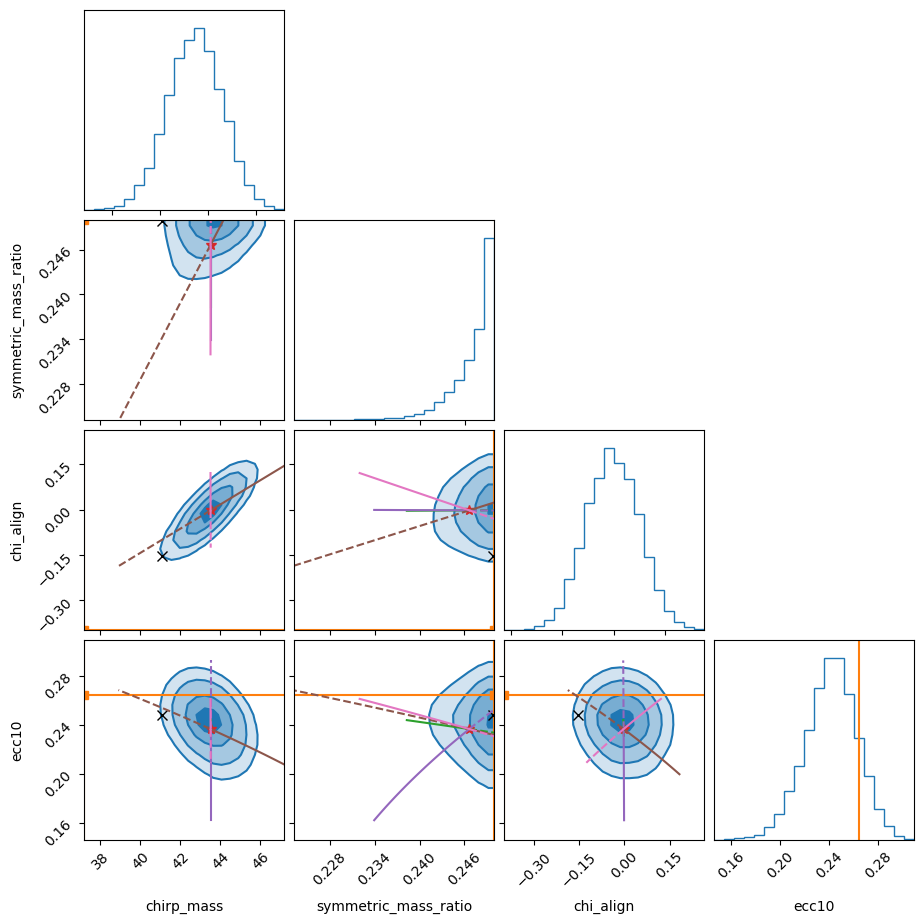

In [144]:
params = ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10']
corner_samples = np.array([samples[key] for key in params]).T
corner_truths = [all_inj_params['posterior_samples'][par][0] for par in params]
fig = corner.corner(corner_samples, truths=corner_truths, color='C0', truth_color='C1', smooth=1, labels=params, plot_density=False, plot_datapoints=False, fill_contours=True)
old_params = [all_peak_params['posterior_samples'][par][0] for par in params]
corner.overplot_points(fig, [old_params], c='C3', label='old peak', marker='*', markersize=7)
delta_params_list = np.matmul(analysis_metric.normalized_evecs().samples, metric_peak)
delta_params = SimplePESamples(SamplesDict(analysis_metric.dx_directions, [[param] for param in delta_params_list]))
new_params = [delta_params[dx][0] + analysis_metric.x[dx][0] for dx in ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd']]
new_params[-1] = np.sqrt(new_params[-1])
corner.overplot_points(fig, [new_params], c='k', label='new peak', marker='x', markersize=7)


axs = fig.get_axes()
lims = {4: [0, 1], 8: [0, 2], 9: [1, 2],
        12: [0, 3], 13: [1, 3], 14: [2, 3]}
ev_cs = ['C2', 'C4', 'C5', 'C6']
for i in range(len(axs)):
    if i not in lims.keys():
        continue

    # Fix limits
    xlim = list(axs[i].get_xlim())
    xlim[0] = np.min([corner_truths[lims[i][0]], xlim[0]])
    xlim[1] = np.max([corner_truths[lims[i][0]], xlim[1]])
    axs[i].set_xlim(xlim)
    ylim = list(axs[i].get_ylim())
    ylim[0] = np.min([corner_truths[lims[i][1]], ylim[0]])
    ylim[1] = np.max([corner_truths[lims[i][1]], ylim[1]])
    axs[i].set_ylim(ylim)

    # Plot eigenvectors
    for ev in range(4):
        dxs_phys = np.outer(np.linspace(0, 1, 101), analysis_metric.normalized_evecs().samples.T[ev]).T
        dxs_phys_pos = [dxs_phys[j] + analysis_metric.x[dx][0] for j, dx in enumerate(['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd'])]
        dxs_phys_neg = [-dxs_phys[j] + analysis_metric.x[dx][0] for j, dx in enumerate(['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd'])]
        dxs_phys_pos[3] = dxs_phys_pos[3]**0.5
        dxs_phys_neg[3] = dxs_phys_neg[3]**0.5
        axs[i].plot(dxs_phys_pos[lims[i][0]], dxs_phys_pos[lims[i][1]], c=ev_cs[ev])
        axs[i].plot(dxs_phys_neg[lims[i][0]], dxs_phys_neg[lims[i][1]], c=ev_cs[ev], ls='dashed')

In [145]:
all_inj_params['posterior_samples']['ecc10sqrd'] = [all_inj_params['posterior_samples']['ecc10'][0]**2]
inj_params_diff_old = [all_inj_params['posterior_samples'][par][0] - all_peak_params['posterior_samples'][par][0] for par in analysis_metric.dx_directions]
inj_dx_diff_old = np.matmul(np.linalg.inv(analysis_metric.normalized_evecs().samples), inj_params_diff_old)
dx_dist_old = np.sqrt(np.dot(inj_dx_diff_old, inj_dx_diff_old))
inj_dx_diff_new = np.array(inj_dx_diff_old) - np.array(metric_peak)
dx_dist_new = np.sqrt(np.dot(inj_dx_diff_new, inj_dx_diff_new))
print(f'Reduced dx distance from {dx_dist_old:.3f} to {dx_dist_new:.3f}')
print(f'This is a mismatch from {analysis_metric.mismatch[0]*dx_dist_old**2:.4f} to {analysis_metric.mismatch[0]*dx_dist_new**2:.4f}')

Reduced dx distance from 2.462 to 1.379
This is a mismatch from 0.0530 to 0.0166


In [117]:
0.0166/3.2**2

0.0016210937499999997

In [118]:
np.sqrt(0.0016/analysis_metric.mismatch[0])

0.4278069280448213